In [7]:
# Project root setup
import os
import sys
from pathlib import Path

ROOT = next((path for path in (Path.cwd(), *Path.cwd().parents) if (path / "src").is_dir()), None)
if ROOT is None:
    raise RuntimeError("Could not locate the project root containing src/.")
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Number of samples - Nonnegative CoLiDE

Replica of `synthetic/notebooks/number_samples.ipynb` for the nonnegative version of CoLiDE
(SCA+Adam, NV and EV) against NOMAD, DAGMA and CoLiDE (EV and NV), under three noise scenarios:
`var=1`, `var=10` and heteroscedastic (sigma_j ~ U(0.5, 5)).

The notebook imports `nonneg_colide/scripts/number_samples.py`, which holds all the experiment code
(methods, hyperparameters, metrics and saving), so the script and the notebook cannot diverge.

- `LOAD = True` (default): loads the results saved in `results/nonneg_colide/samples/` and plots them.
- `LOAD = False`: runs the experiment from the notebook (hours). To run it in the background use instead:

```
nohup .venv-dag/bin/python nonneg_colide/scripts/number_samples.py > logs/salida_nonneg_colide_samples.txt 2>&1 &
```

Metrics: SHD (mean +- std), normalized Frobenius error of W (median and 25-75 percentiles) and, for the methods
that estimate Sigma, the Sigma error computed after normalizing both vectors (same criterion as the error of W).

In [8]:
import importlib.util

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import src.utils as utils

# Import the experiment script as a module (methods, metrics, saving and plotting live there)
spec = importlib.util.spec_from_file_location("ns", ROOT / "nonneg_colide" / "scripts" / "number_samples.py")
ns = importlib.util.module_from_spec(spec)
spec.loader.exec_module(ns)

LOAD = True            # True: load saved results; False: run the experiment from the notebook
SAVE_FIGS = False      # save the figures next to the results
RESULTS_DIR = None     # None -> results/nonneg_colide/samples/ ; e.g. "results/nonneg_colide/samples_smoke/"

ns.LOAD = LOAD
ns.SAVE = not LOAD
if RESULTS_DIR is not None:
    ns.PATH = str(ROOT / RESULTS_DIR) + os.sep
os.makedirs(ns.PATH, exist_ok=True)
print("Results folder:", ns.PATH)

Results folder: /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/


## Configuration

In [9]:
n_dags = 100
n_samples_values = np.array([50, 60, 80, 100, 200, 500, 1000, 5000, 10000])
thr = .2
verb = True

Exps = ns.build_experiments()
scenarios = {sc["name"]: sc for sc in ns.build_scenarios(n_nodes=100)}

pd.DataFrame([{"leg": e["leg"], "model": e["model"].__name__, "sigma": e["sigma"], "adapt_lamb": e["adapt_lamb"],
               **e.get("init", {}), **e["args"]} for e in Exps]).set_index("leg")

,model,sigma,adapt_lamb,primal_opt,acyclicity,equal_var,stepsize,step_type,alpha_0,rho_0,...,iters_in,iters_out,beta,sca_adam,loss_type,lambda1,T,warm_iter,max_iter,lr
leg,,,,,,,,,,,,,,,,,,,,,
NN-CoLiDE-NV,MetMulColide,True,True,sca,logdet,False,0.0003,fixed,0.01,0.05,...,30000.0,10.0,2.0,True,NaN,NaN,NaN,NaN,NaN,NaN
NN-CoLiDE-EV,MetMulColide,True,True,sca,logdet,True,0.0003,fixed,0.01,0.05,...,30000.0,10.0,2.0,True,NaN,NaN,NaN,NaN,NaN,NaN
NOMAD-adam,MetMulDagma,False,True,adam,logdet,NaN,0.0050,fixed,0.10,0.10,...,5000.0,10.0,1.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DAGMA,DAGMA_linear,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,l2,0.05,4.0,20000.0,70000.0,0.0003
CoLiDE-EV,colide_ev,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.05,4.0,20000.0,70000.0,0.0003
CoLiDE-NV,colide_nv,True,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.05,4.0,20000.0,70000.0,0.0003


## Plotting helpers

In [10]:
results = {}


def run_or_load(name, skip=()):
    sc = scenarios[name]
    out = ns.run_or_load_samples_results(sc["data_params"], n_samples_values, Exps, n_dags, sc["name"], thr=thr, verb=verb)
    *metrics, exps_out, xvals = out
    results[name] = {"metrics": dict(zip(ns.METRIC_NAMES, metrics)), "exps": exps_out, "xvals": xvals, "scenario": sc}
    return results[name]


def show_scenario(name, skip=()):
    res = run_or_load(name)
    m, exps_out, xvals, sc = res["metrics"], res["exps"], res["xvals"], res["scenario"]
    skip = list(skip)
    prefix = ns.samples_results_prefix(sc["name"])

    # SHD (mean +- std) and Fro error (median, prctiles 25-75)
    fig, _ = utils.plot_shd_error_pair(m["shd"], m["err"], exps_out, xvals, xlabel="Number of samples",
                                       shd_ylabel="SHD", err_ylabel="Fro Error", skip_idx=skip, alpha=.25,
                                       shd_agg="mean", shd_deviation="std", err_agg="median", err_deviation="prctile",
                                       err_plot_func="loglog", figsize=(10, 5), title=sc["title"])
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_summary.png", bbox_inches="tight")

    # Sigma error (only methods that estimate Sigma)
    fig, _ = ns.plot_sigma_error(m["err_sig"], exps_out, xvals, skip_idx=skip, title=f'{sc["title"]} - Sigma error')
    if SAVE_FIGS:
        fig.savefig(f"{prefix}_sigma_error.png", bbox_inches="tight")

    # Tables at each number of samples
    legs = [e["leg"] for e in exps_out]
    for metric, agg, label in [("shd", np.mean, "SHD (mean)"), ("err", np.median, "Fro error (median)"),
                               ("err_sig", np.nanmedian, "Sigma error (median)"), ("runtime", np.mean, "time (mean, s)")]:
        with np.errstate(all="ignore"):
            table = pd.DataFrame(agg(m[metric], axis=0), index=xvals, columns=legs).rename_axis("samples")
        print(f"\n{sc['title']} - {label}")
        display(table.round(4))
    return res


def show_all_metrics(name, agg="mean", skip=()):
    m, exps_out, xvals = results[name]["metrics"], results[name]["exps"], results[name]["xvals"]
    utils.plot_all_metrics(m["shd"], m["tpr"], m["fdr"], m["fscore"], m["err"], m["acyc"], m["runtime"],
                           m["dag_count"], xvals, exps_out, skip_idx=list(skip), agg=agg)

## Scenario 1: variance 1

[2026-09-14T18:18:51 pid=18563] Loaded samples results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/samples_er4_N100_var1.npz

var = 1 - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,190.56,158.79,93.10,390.92,583.47,909.10
60,138.66,119.95,67.41,307.53,466.47,706.06
80,82.01,72.82,35.95,191.57,274.53,339.88
100,42.43,36.95,18.98,116.69,152.13,181.55
200,7.34,5.54,1.86,39.19,41.52,49.69
500,1.03,0.26,0.07,26.30,28.41,34.53
1000,0.79,0.14,0.02,25.15,25.54,30.31
5000,0.74,0.19,0.04,23.96,25.61,31.42
10000,0.64,0.09,0.00,24.88,26.29,32.73



var = 1 - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.2239,0.1898,0.1774,0.5368,0.6448,0.8420
60,0.1618,0.1461,0.1400,0.4159,0.5204,0.6762
80,0.1099,0.0998,0.0883,0.2901,0.3459,0.3961
100,0.0728,0.0663,0.0589,0.2099,0.2378,0.2723
200,0.0313,0.0284,0.0223,0.1113,0.1067,0.1248
500,0.0117,0.0104,0.0079,0.0694,0.0687,0.0802
1000,0.0057,0.0051,0.0039,0.0628,0.0606,0.0689
5000,0.0010,0.0009,0.0007,0.0524,0.0553,0.0634
10000,0.0005,0.0005,0.0003,0.0571,0.0583,0.0680



var = 1 - Sigma error (median)


/usr/local/lib/python3.8/dist-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.0459,0.0,NaN,NaN,0.0,0.4434
60,0.0275,0.0,NaN,NaN,0.0,0.2263
80,0.0161,0.0,NaN,NaN,0.0,0.0598
100,0.0105,0.0,NaN,NaN,0.0,0.0347
200,0.0037,0.0,NaN,NaN,0.0,0.0130
500,0.0013,0.0,NaN,NaN,0.0,0.0100
1000,0.0006,0.0,NaN,NaN,0.0,0.0086
5000,0.0001,0.0,NaN,NaN,0.0,0.0090
10000,0.0001,0.0,NaN,NaN,0.0,0.0095



var = 1 - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,39.4664,41.3999,23.9281,38.8915,59.9634,131.4840
60,32.2261,37.5367,22.8572,34.4380,50.1405,104.3665
80,26.9535,34.1632,21.6331,33.1753,43.1859,46.1563
100,26.4814,31.9726,21.2960,31.1737,41.5774,44.7991
200,24.5599,29.4879,20.6334,29.5306,37.2116,38.2490
500,24.8724,30.0896,21.0174,29.0821,35.7315,37.5904
1000,24.1708,30.2594,21.0830,27.0863,32.4893,32.9228
5000,21.3071,27.1409,19.5510,23.2929,28.9077,28.3351
10000,18.6070,23.4409,17.5031,20.2427,23.4524,24.1666


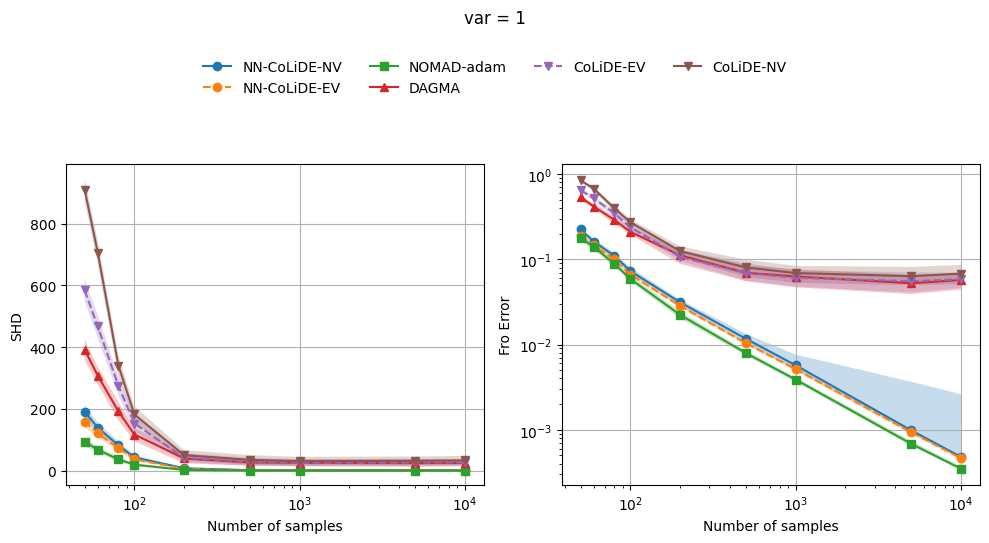

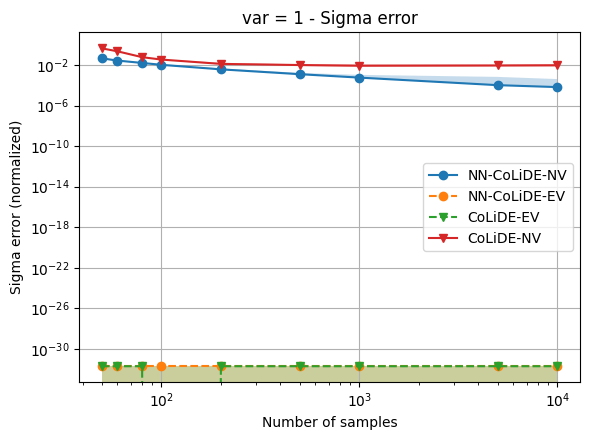

In [11]:
skip = []
res = show_scenario("er4_N100_var1", skip=skip)

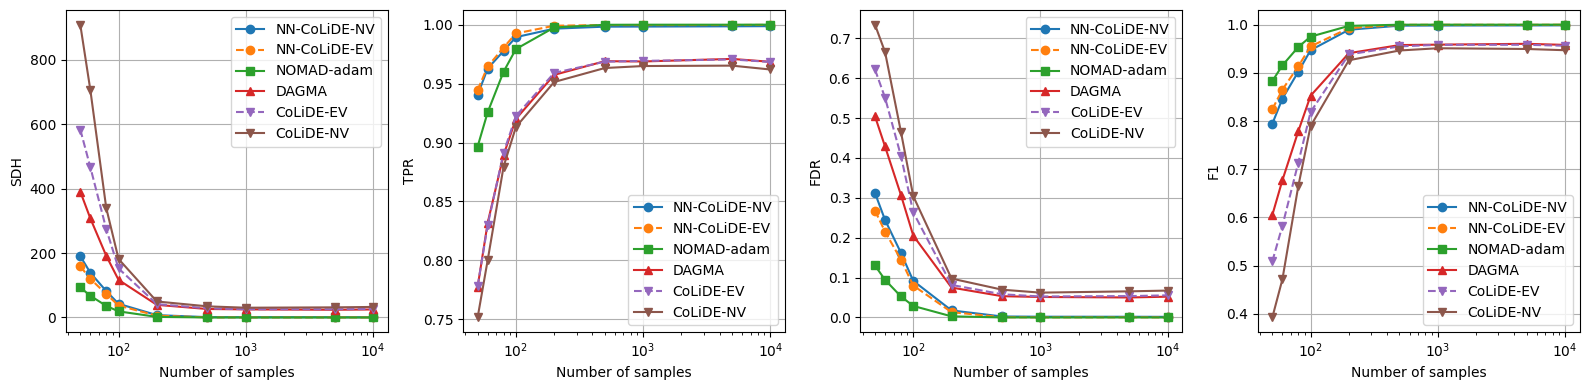

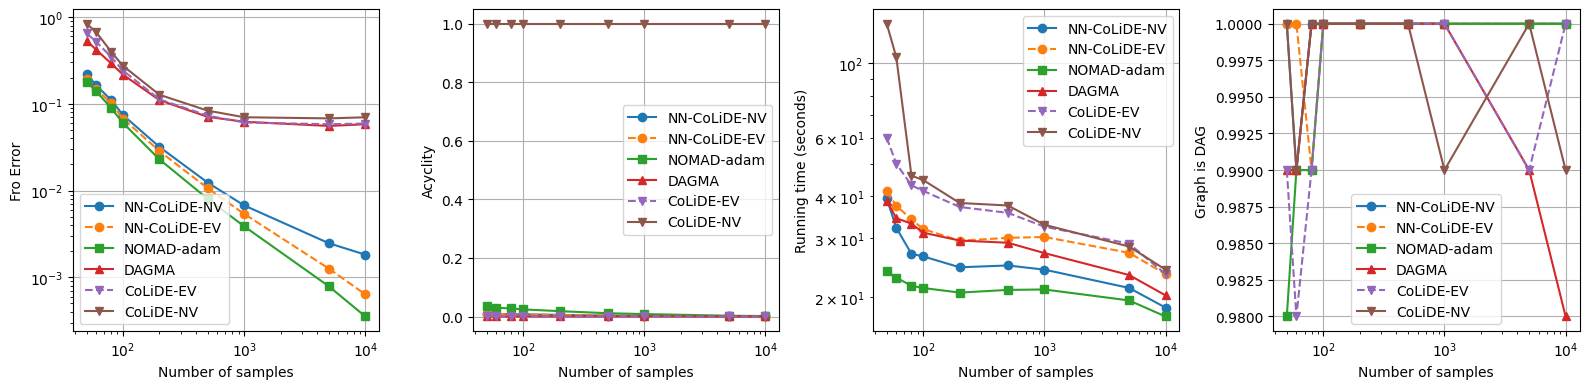

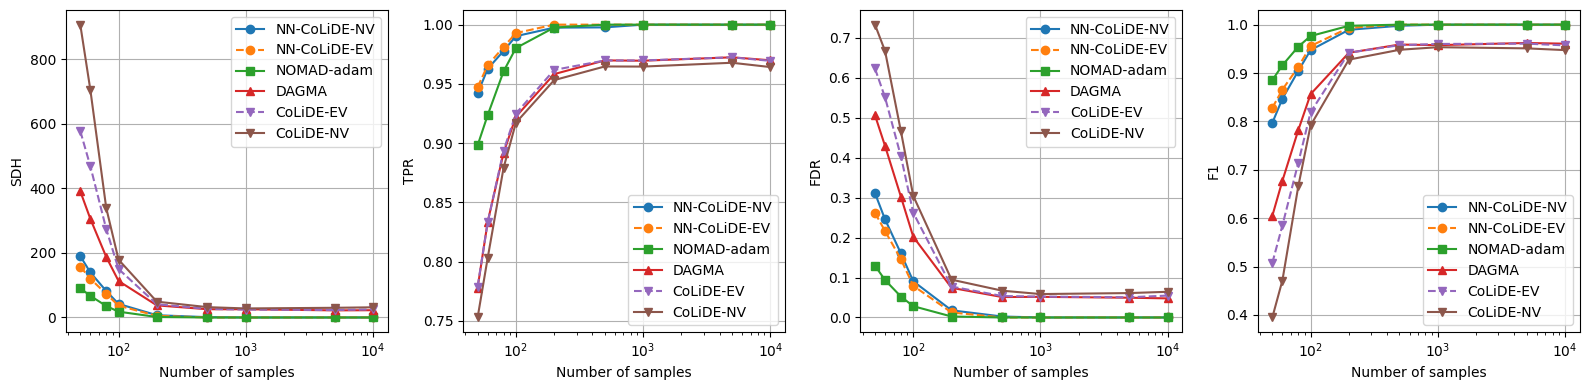

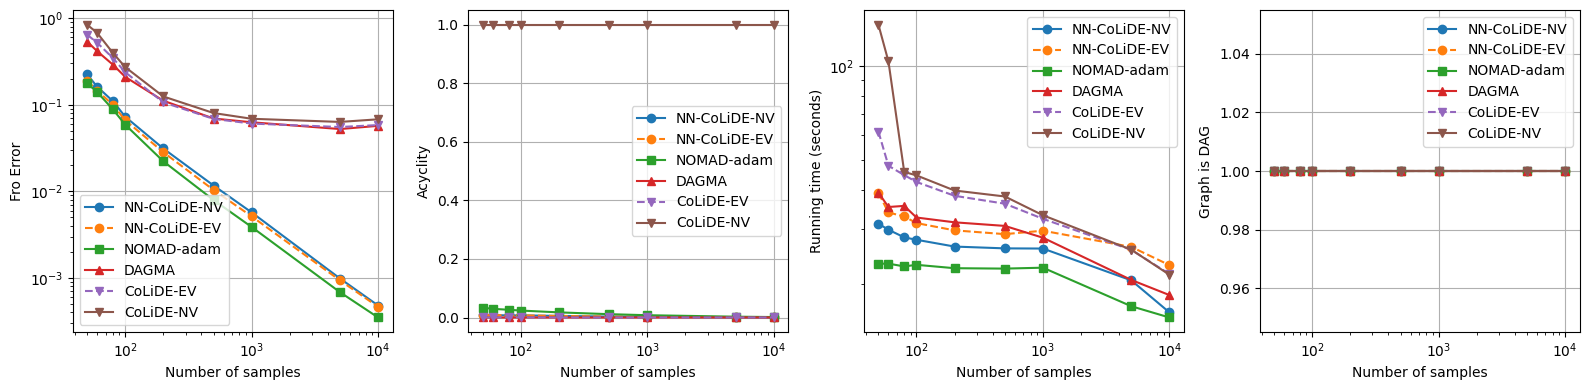

In [12]:
show_all_metrics("er4_N100_var1", agg="mean", skip=skip)
show_all_metrics("er4_N100_var1", agg="median", skip=skip)

## Scenario 2: variance 10

[2026-09-14T18:18:56 pid=18563] Loaded samples results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/samples_er4_N100_var10.npz

var = 10 - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,408.89,336.88,368.32,1181.62,1093.09,1486.72
60,320.17,276.13,309.48,1212.60,1050.75,1543.00
80,211.16,192.88,222.25,1094.34,833.25,1244.47
100,126.49,116.28,141.06,835.50,571.07,738.95
200,29.66,27.67,37.53,304.12,156.75,194.37
500,1.55,1.40,2.27,94.59,53.19,82.68
1000,0.12,0.02,0.54,68.24,42.38,73.38
5000,0.01,0.00,0.00,56.37,37.52,65.24
10000,0.07,0.00,0.02,58.71,40.43,64.32



var = 10 - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.4144,0.3199,0.3495,0.9873,0.9294,1.0976
60,0.2831,0.2408,0.2622,0.9183,0.8314,1.0354
80,0.1811,0.1645,0.1818,0.7843,0.6424,0.8554
100,0.1216,0.1132,0.1271,0.6361,0.4842,0.5713
200,0.0493,0.0472,0.0532,0.3442,0.2248,0.2653
500,0.0179,0.0175,0.0198,0.2099,0.1205,0.1571
1000,0.0086,0.0085,0.0097,0.1729,0.0939,0.1365
5000,0.0016,0.0016,0.0018,0.1412,0.0757,0.1081
10000,0.0008,0.0008,0.0009,0.1436,0.0781,0.1152



var = 10 - Sigma error (median)


/usr/local/lib/python3.8/dist-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.0664,0.0,NaN,NaN,0.0,0.6091
60,0.0387,0.0,NaN,NaN,0.0,0.4575
80,0.0200,0.0,NaN,NaN,0.0,0.1920
100,0.0123,0.0,NaN,NaN,0.0,0.0656
200,0.0038,0.0,NaN,NaN,0.0,0.0137
500,0.0012,0.0,NaN,NaN,0.0,0.0098
1000,0.0006,0.0,NaN,NaN,0.0,0.0104
5000,0.0001,0.0,NaN,NaN,0.0,0.0098
10000,0.0001,0.0,NaN,NaN,0.0,0.0097



var = 10 - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,65.0590,52.5420,35.1034,56.1776,73.3203,128.6262
60,50.0689,46.0575,30.2400,48.0390,66.5753,127.3828
80,42.3047,42.9942,27.8992,45.0351,57.9279,110.3205
100,42.2552,42.3985,29.1646,42.4988,53.6229,64.2122
200,34.1490,37.0506,26.2252,34.4564,43.0432,46.9318
500,33.1239,36.7975,27.0561,33.4194,41.3968,44.4696
1000,34.2026,40.0927,27.5684,32.2124,38.5256,42.4339
5000,31.1991,34.5998,25.6681,28.6628,33.0674,35.2952
10000,25.7706,28.9658,20.0256,21.9425,26.7069,28.3794


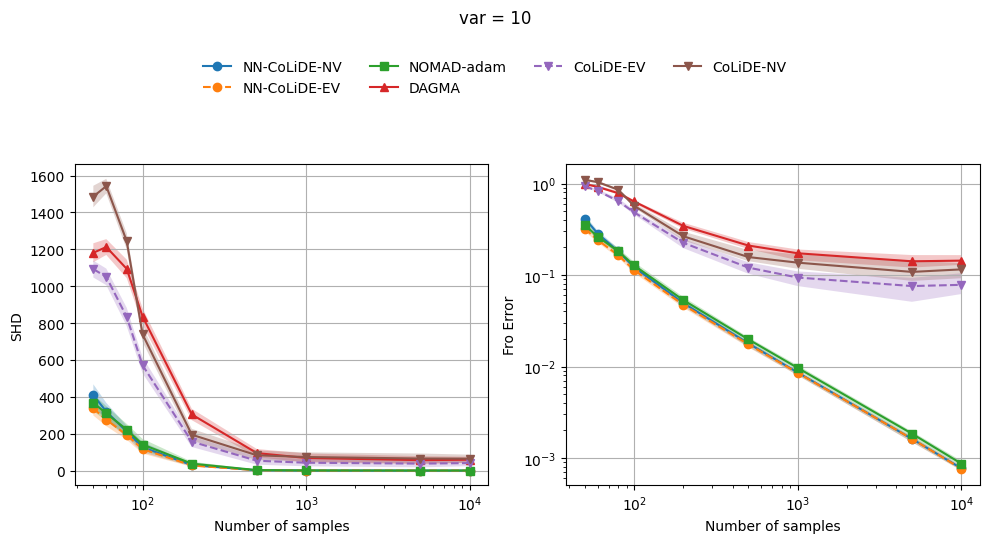

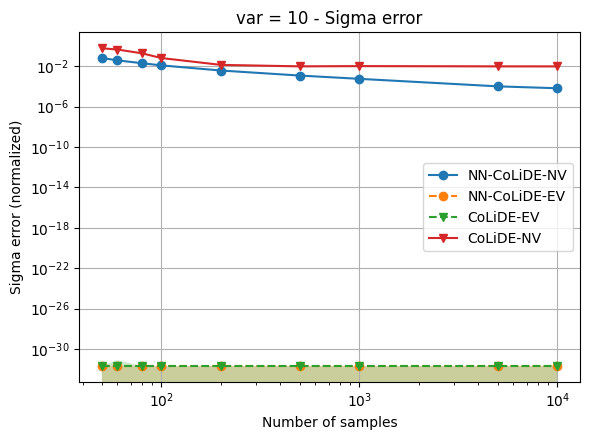

In [13]:
skip = []
res = show_scenario("er4_N100_var10", skip=skip)

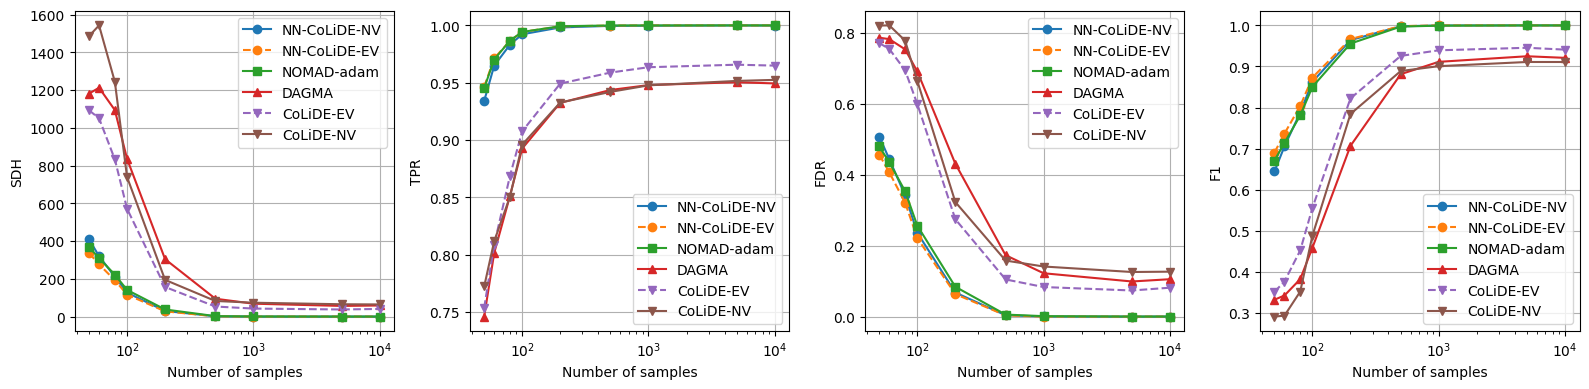

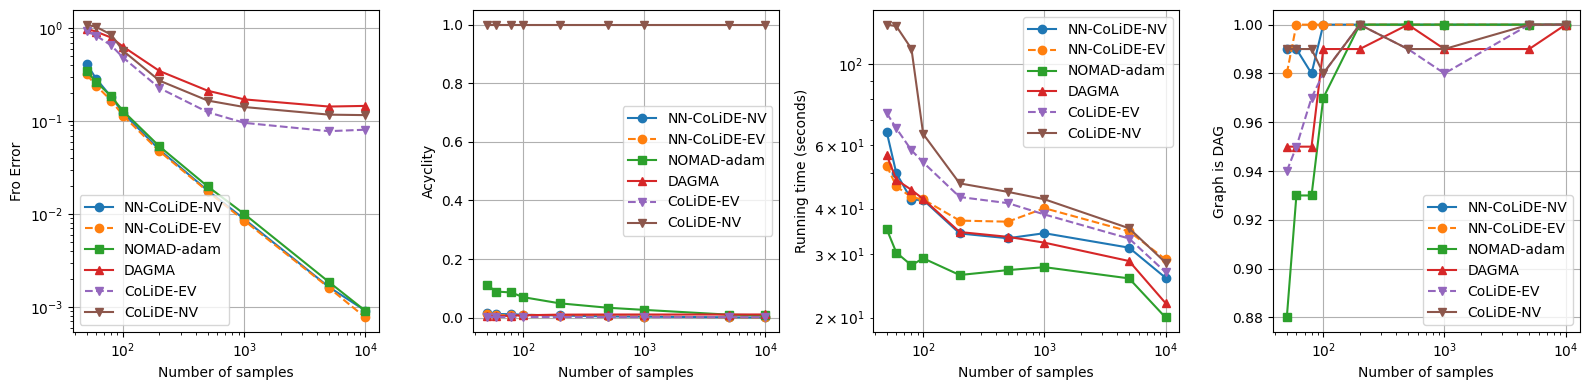

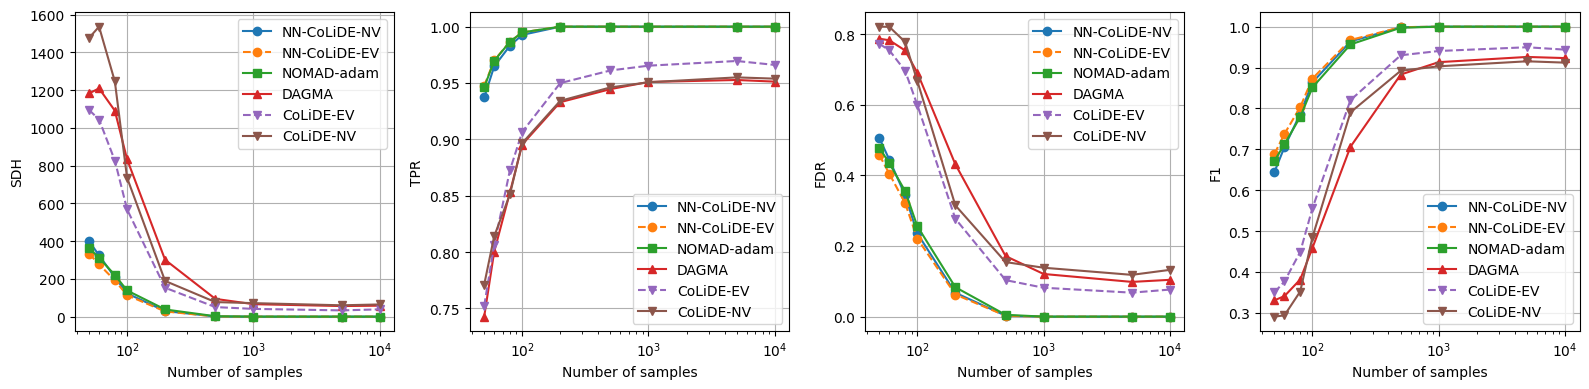

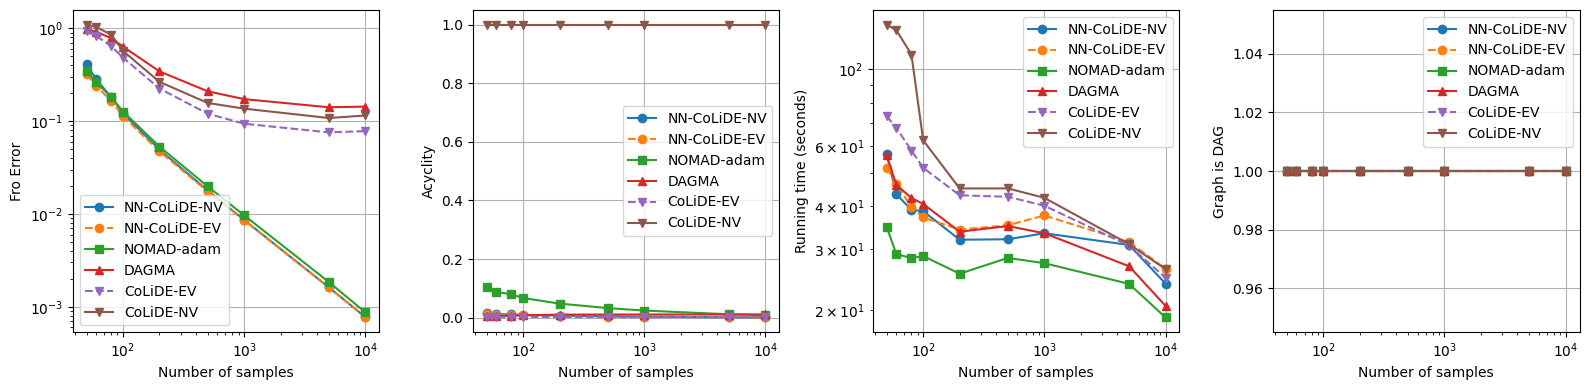

In [14]:
show_all_metrics("er4_N100_var10", agg="mean", skip=skip)
show_all_metrics("er4_N100_var10", agg="median", skip=skip)

## Scenario 3: heteroscedastic, sigma_j ~ U(0.5, 5)

[2026-09-14T18:19:01 pid=18563] Loaded samples results from /home/srey/Investigacion/nonneg_dag_learning/nomad/results/nonneg_colide/samples/samples_er4_N100_hetero.npz

heteroscedastic - SHD (mean)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,400.18,352.90,374.81,1304.49,1263.12,1510.04
60,327.92,307.89,330.72,1382.49,1258.06,1527.65
80,243.74,242.59,266.77,1347.92,1090.02,1151.55
100,173.90,179.75,201.57,1181.63,881.07,809.30
200,81.56,95.09,110.22,734.99,512.19,432.96
500,28.22,40.04,46.36,455.20,351.47,317.48
1000,15.18,25.44,29.66,388.90,322.81,297.13
5000,10.95,20.52,21.33,355.26,308.65,282.37
10000,10.26,18.61,19.33,355.52,311.71,286.39



heteroscedastic - Fro error (median)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.5191,0.4894,0.5100,1.2530,1.2656,1.3016
60,0.4132,0.4180,0.4358,1.2534,1.2220,1.2680
80,0.3003,0.3214,0.3400,1.2086,1.1110,1.1078
100,0.2190,0.2452,0.2611,1.1195,0.9890,0.9074
200,0.1209,0.1445,0.1579,0.9199,0.8144,0.7534
500,0.0712,0.0863,0.0934,0.8134,0.7334,0.6917
1000,0.0519,0.0707,0.0767,0.7783,0.7019,0.6738
5000,0.0410,0.0618,0.0675,0.7514,0.6828,0.6391
10000,0.0426,0.0620,0.0642,0.7563,0.6943,0.6610



heteroscedastic - Sigma error (median)


/usr/local/lib/python3.8/dist-packages/numpy/lib/nanfunctions.py:1217: RuntimeWarning: All-NaN slice encountered
  r, k = function_base._ureduce(a, func=_nanmedian, axis=axis, out=out,


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,0.0879,0.1743,NaN,NaN,0.1743,0.7208
60,0.0607,0.1743,NaN,NaN,0.1743,0.5595
80,0.0421,0.1743,NaN,NaN,0.1743,0.3035
100,0.0397,0.1743,NaN,NaN,0.1743,0.2207
200,0.0252,0.1743,NaN,NaN,0.1743,0.1844
500,0.0219,0.1743,NaN,NaN,0.1743,0.1778
1000,0.0228,0.1743,NaN,NaN,0.1743,0.1830
5000,0.0236,0.1743,NaN,NaN,0.1743,0.1785
10000,0.0274,0.1743,NaN,NaN,0.1743,0.1832



heteroscedastic - time (mean, s)


,NN-CoLiDE-NV,NN-CoLiDE-EV,NOMAD-adam,DAGMA,CoLiDE-EV,CoLiDE-NV
samples,,,,,,
50,74.1800,61.9401,33.6404,60.2171,85.4456,129.5671
60,60.2992,57.4750,30.7038,60.0654,78.8108,128.6191
80,56.2180,55.3850,29.3509,50.9884,62.5532,92.9533
100,52.0824,50.8974,29.3727,49.5731,59.2048,67.0067
200,45.3511,46.4082,29.9942,41.1350,51.3249,55.7652
500,51.5142,52.3293,32.6037,40.2590,51.6884,58.1070
1000,51.1956,51.4062,31.1486,37.3669,47.0552,50.3690
5000,47.9868,49.8483,29.1919,33.2990,40.4967,41.7369
10000,37.8770,38.3156,24.1779,27.1460,32.6459,33.2473


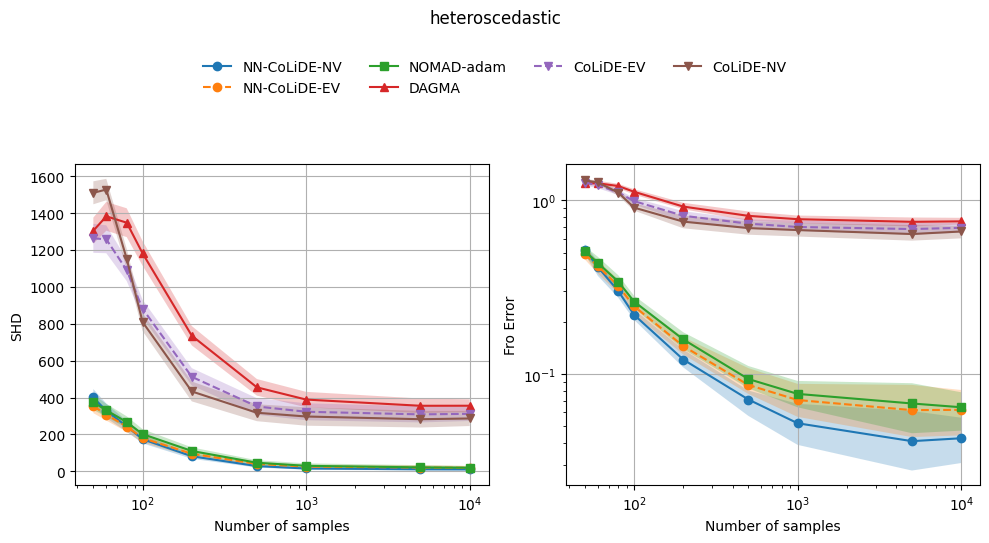

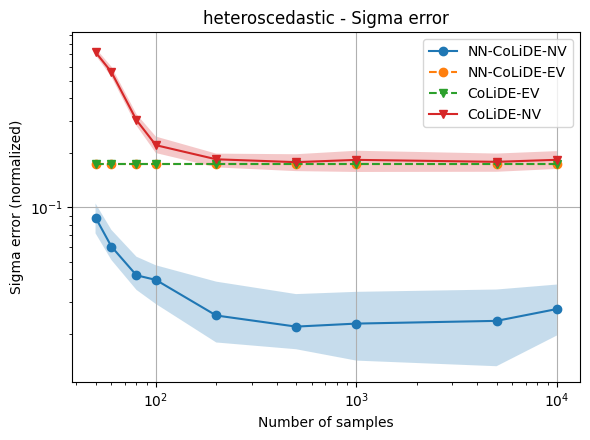

In [15]:
skip = []
res = show_scenario("er4_N100_hetero", skip=skip)

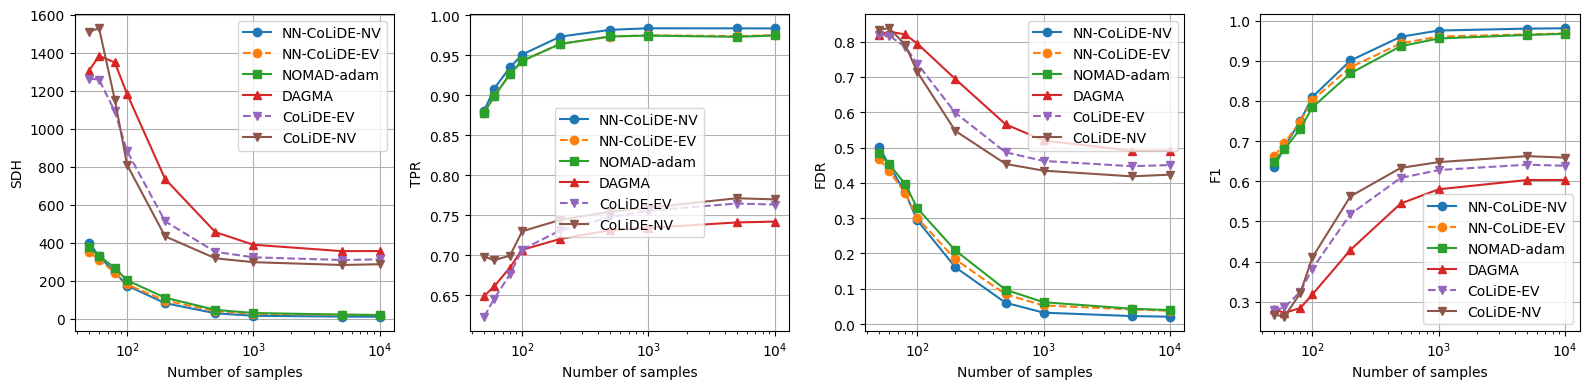

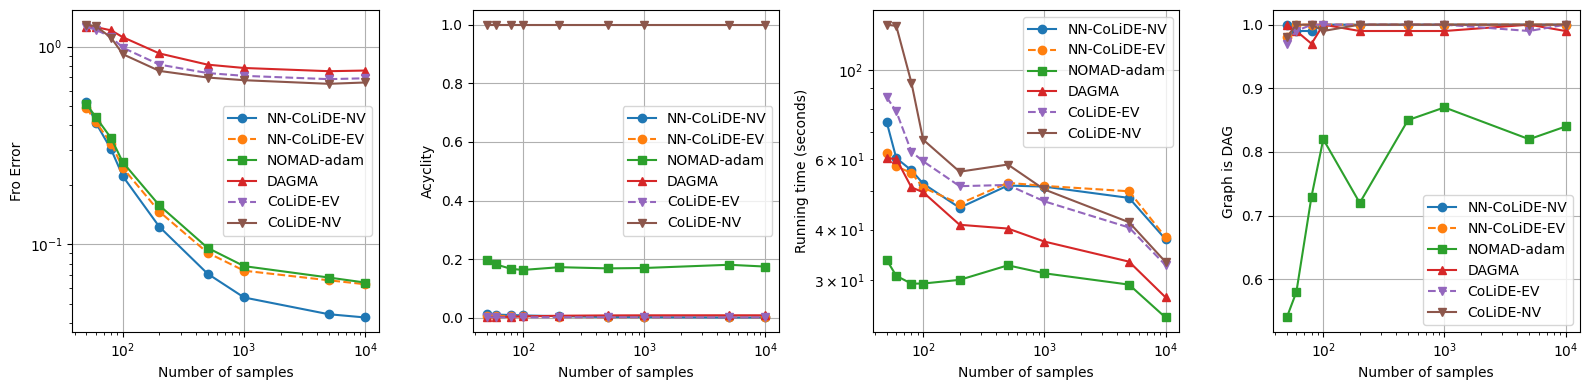

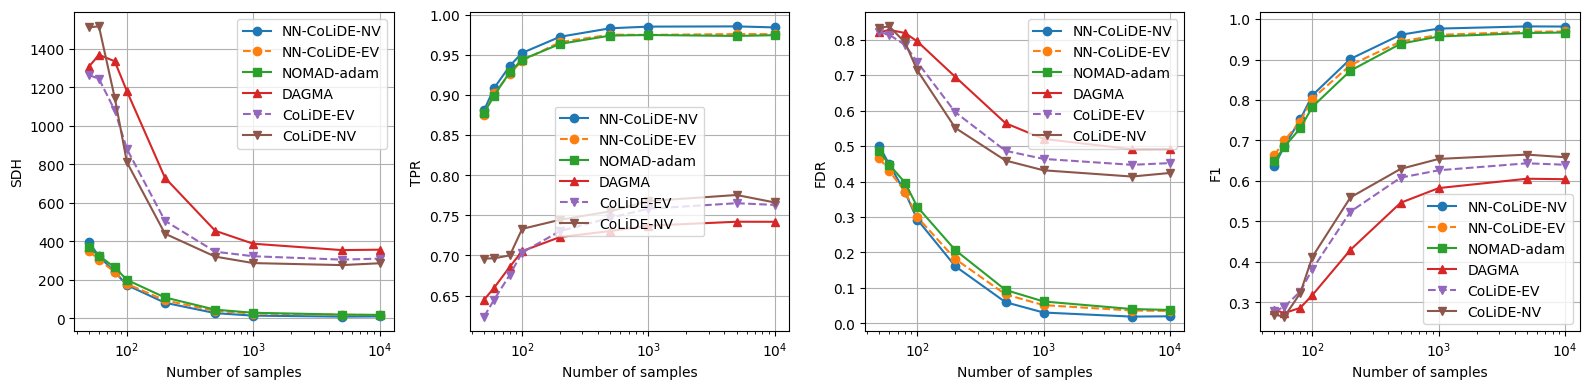

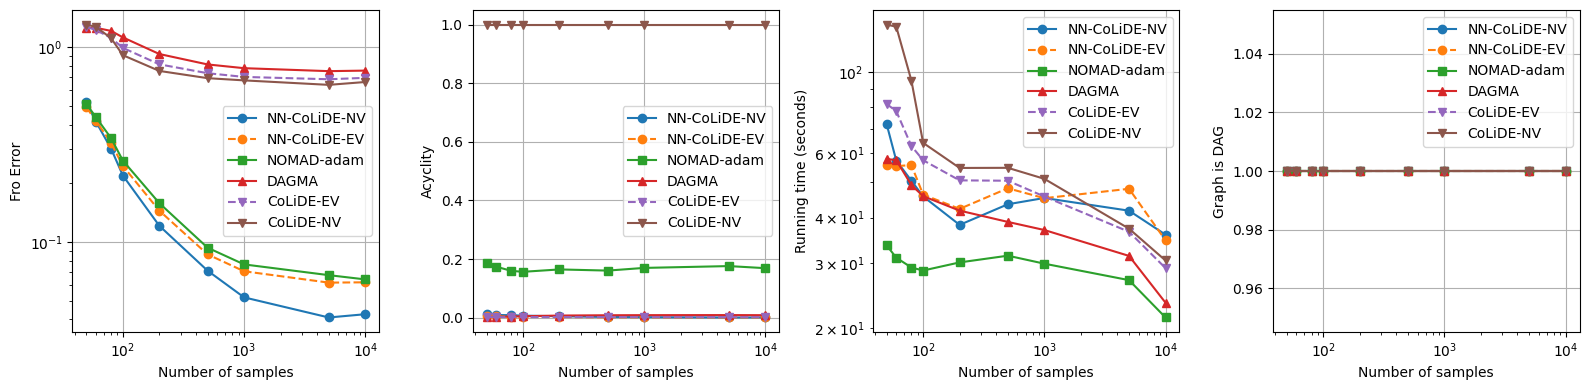

In [16]:
show_all_metrics("er4_N100_hetero", agg="mean", skip=skip)
show_all_metrics("er4_N100_hetero", agg="median", skip=skip)

## Joint comparison of the three scenarios

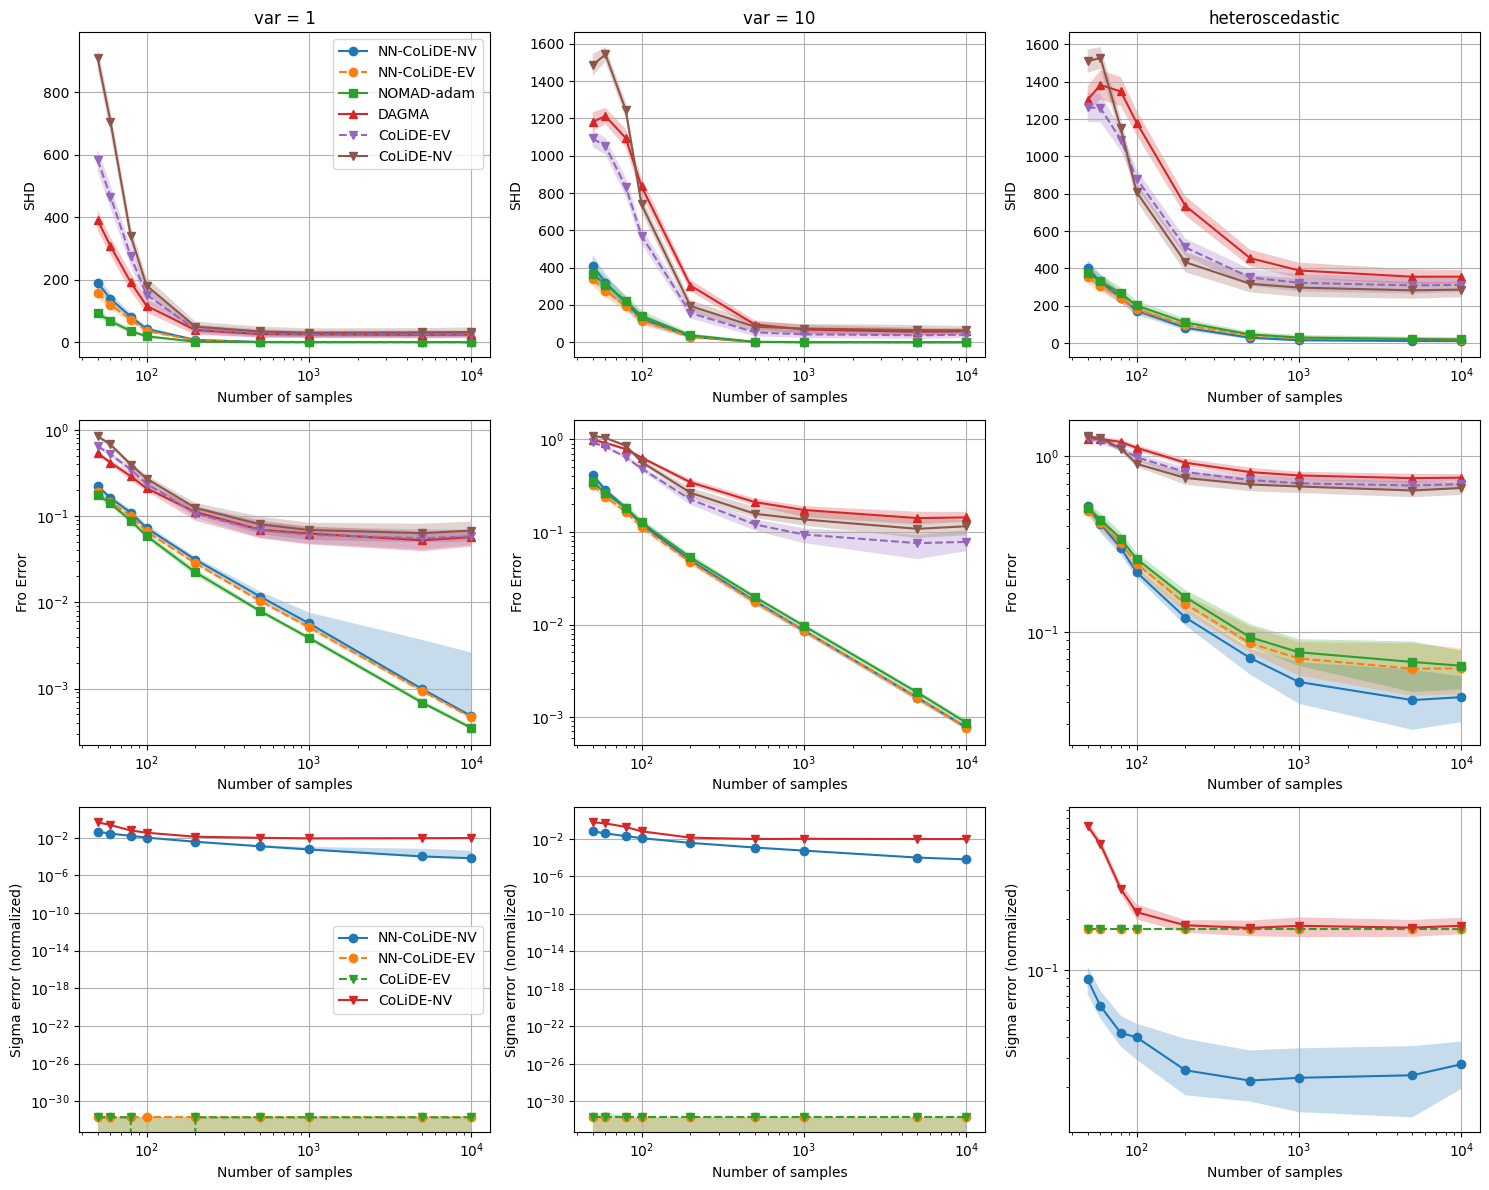

In [17]:
names = [n for n in scenarios if n in results]
skip = []
fig, axes = plt.subplots(3, len(names), figsize=(5 * len(names), 12), squeeze=False)
for c, name in enumerate(names):
    m, exps_out, xvals, sc = results[name]["metrics"], results[name]["exps"], results[name]["xvals"], results[name]["scenario"]
    utils.plot_data(axes[0, c], m["shd"], exps_out, xvals, "Number of samples", "SHD", skip,
                    agg="mean", deviation="std", alpha=.25, legend=(c == 0))
    utils.plot_data(axes[1, c], m["err"], exps_out, xvals, "Number of samples", "Fro Error", skip,
                    agg="median", deviation="prctile", alpha=.25, plot_func="loglog", legend=False)
    utils.plot_data(axes[2, c], m["err_sig"], exps_out, xvals, "Number of samples", "Sigma error (normalized)",
                    ns.sigma_skip_idx(exps_out, skip), agg="median", deviation="prctile", alpha=.25,
                    plot_func="loglog", legend=(c == 0))
    axes[0, c].set_title(sc["title"])
plt.tight_layout()
if SAVE_FIGS:
    fig.savefig(f"{ns.PATH}samples_joint_scenarios.png", bbox_inches="tight")